# 🌿 EcoYield — LSTM Sales Forecasting
**Corporación Favorita Grocery Dataset**

This notebook covers the full ML pipeline:
1. Data loading & quality checks
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Scaling & sequence creation
5. Train / Validation / Test split (chronological)
6. LSTM model with BatchNorm + L2 regularization
7. Training with callbacks
8. Evaluation: RMSE, MAE, MAPE, R²
9. Diagnostic plots: residuals, QQ, ACF
10. Model & artefact saving

---
## 1️⃣ Imports & Configuration

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
import joblib
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.regularizers import l2

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ──
DATA_PATH  = '../Data/Raw/train.csv'
MODEL_DIR  = '../model'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Plot style ──
plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#111827',
    'axes.edgecolor':   '#1C2333',
    'axes.labelcolor':  '#9BAEC8',
    'xtick.color':      '#9BAEC8',
    'ytick.color':      '#9BAEC8',
    'text.color':       '#ECEFF4',
    'grid.color':       '#1C2333',
    'axes.grid':        True,
    'font.family':      'DejaVu Sans',
    'figure.dpi':       110,
})
COLORS = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12', '#9B59B6']

print('Imports done | TF:', tf.__version__)


Imports done | TF: 2.21.0


---
## 2️⃣ Data Loading & Quality Checks

In [2]:
SAMPLE_SIZE = 15,000,000

# ── Load real data if the CSV exists; otherwise generate synthetic data ──────
# This lets the entire notebook run end-to-end even without the Favorita file.
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, parse_dates=['date'])

#  sample WITHOUT full sort first
    df = df.sample(n=15000000, random_state=50)

#  faster sort (only needed column)
    df = df.sort_values('date', kind='mergesort')
    
    df = df[['date', 'unit_sales', 'onpromotion']].copy()
    df.columns = ['date', 'sales', 'promo']
    n_neg       = (df['sales'] < 0).sum()
    df['sales'] = df['sales'].clip(lower=0)
    n_promo_nan = df['promo'].isna().sum()
    df['promo'] = df['promo'].fillna(0).astype(int)
    df          = df.sort_values('date').reset_index(drop=True)
    print(f'Shape         : {df.shape}')
    print(f'Date range    : {df["date"].min().date()} → {df["date"].max().date()}')
    print(f'Negative sales clipped : {n_neg:,}')
    print(f'Promo NaN filled       : {n_promo_nan:,}')
else:
    print(f'  {DATA_PATH} not found — using SYNTHETIC data for pipeline testing.')
    np.random.seed(SEED)
    dates_rng = pd.date_range('2015-01-01', periods=730, freq='D')
    rows = []
    for d in dates_rng:
        for store_id in range(1, 11):          # 10 synthetic stores × 730 days
            base  = 30 + 15 * np.sin(2 * np.pi * d.dayofyear / 365)  # yearly seasonality
            noise = np.random.normal(0, 6)
            sales = float(max(0.0, base + noise))
            promo = int(np.random.rand() < 0.12)
            rows.append({'date': d, 'sales': sales, 'promo': promo})
    df = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
    print(f'Synthetic df  : {df.shape}  ({df["date"].nunique()} unique dates)')

print(f'\nNull counts:\n{df.isnull().sum()}')
df.head()


Shape         : (15000000, 3)
Date range    : 2013-01-01 → 2017-08-15
Negative sales clipped : 891
Promo NaN filled       : 2,588,050

Null counts:
date     0
sales    0
promo    0
dtype: int64


,date,sales,promo
0,2013-01-01,5.0,0
1,2013-01-01,4.0,0
2,2013-01-01,15.0,0
3,2013-01-01,1.0,0
4,2013-01-01,8.0,0


In [3]:
print('── Descriptive Statistics ──')
display(df.describe().round(2))

print(f'\nZero-sales rows  : {(df["sales"] == 0).sum():,}  ({(df["sales"] == 0).mean()*100:.1f}%)')
print(f'Promo rows       : {df["promo"].sum():,}  ({df["promo"].mean()*100:.1f}%)')

── Descriptive Statistics ──


,date,sales,promo
count,15000000,15000000.00,15000000.00
mean,2015-09-15 16:56:39.189119488,8.55,0.06
min,2013-01-01 00:00:00,0.00,0.00
25%,2014-09-20 00:00:00,2.00,0.00
50%,2015-11-21 00:00:00,4.00,0.00
75%,2016-10-17 00:00:00,9.00,0.00
max,2017-08-15 00:00:00,11032.00,1.00
std,NaN,21.28,0.24



Zero-sales rows  : 891  (0.0%)
Promo rows       : 934,525  (6.2%)


---
## 3️⃣ Exploratory Data Analysis (EDA)

In [4]:
# ── Aggregate to daily totals (item-store → national day) ──
df_daily = (
    df.groupby('date')
    .agg(sales=('sales', 'sum'), promo=('promo', 'sum'))
    .reset_index()
    .sort_values('date')
    .reset_index(drop=True)
)
df_daily['ma7']  = df_daily['sales'].rolling(7,  min_periods=1).mean()
df_daily['ma30'] = df_daily['sales'].rolling(30, min_periods=1).mean()

assert not df_daily.empty, (
    "df_daily is empty after groupby — the raw df must be empty. "
    "Re-run Cell 4 and check that `df` printed a non-zero shape."
)
print(f'Daily aggregated shape : {df_daily.shape}')
df_daily.head()


Daily aggregated shape : (1684, 5)


,date,sales,promo,ma7,ma30
0,2013-01-01,312.739,0,312.7390,312.7390
1,2013-01-02,58152.333,0,29232.5360,29232.5360
2,2013-01-03,41041.751,0,33168.9410,33168.9410
3,2013-01-04,41997.917,0,35376.1850,35376.1850
4,2013-01-05,59463.217,0,40193.5914,40193.5914


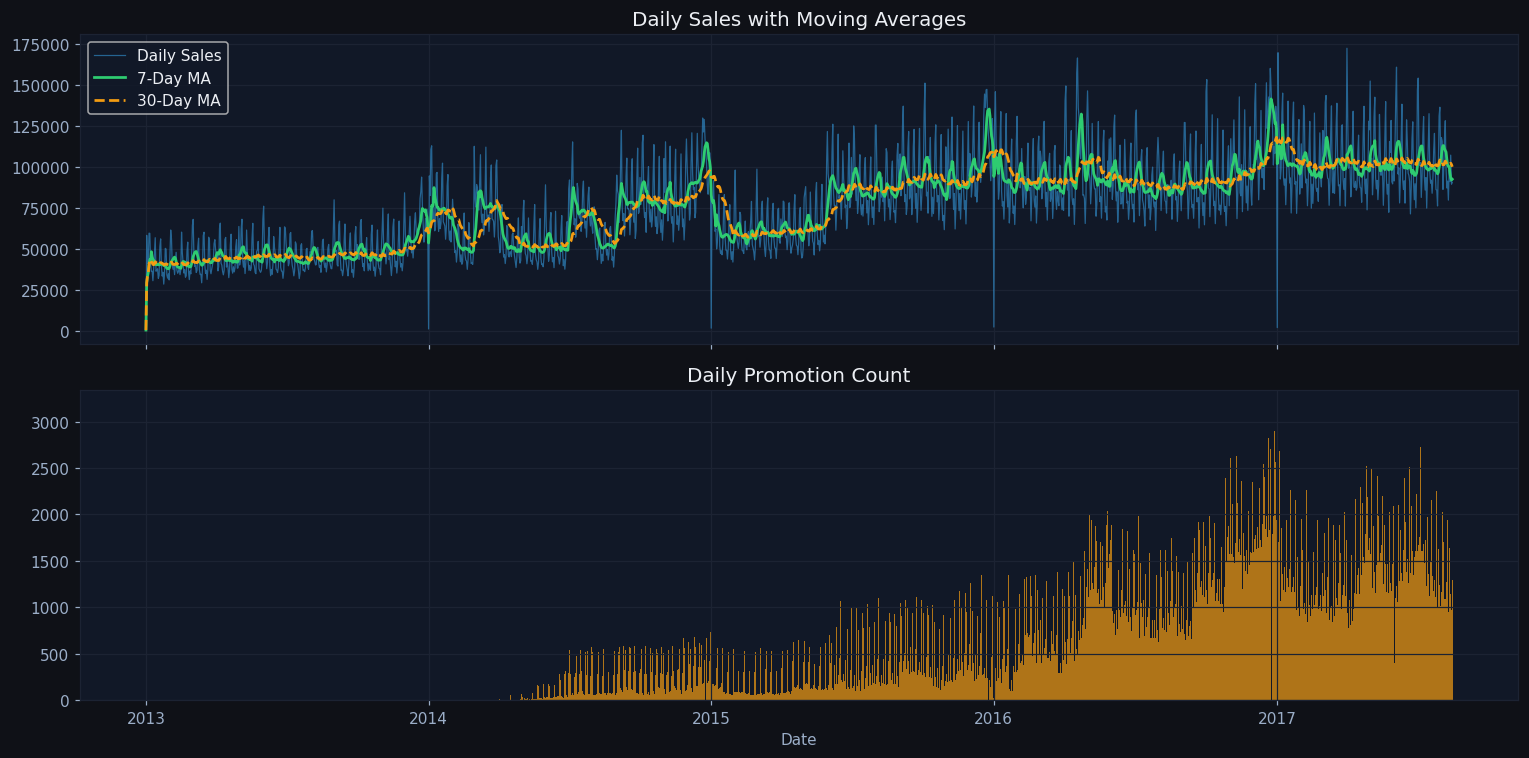

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel 1: raw + moving averages
axes[0].plot(df_daily['date'], df_daily['sales'], color=COLORS[1], lw=0.8, alpha=0.6, label='Daily Sales')
axes[0].plot(df_daily['date'], df_daily['ma7'],   color=COLORS[0], lw=1.8, label='7-Day MA')
axes[0].plot(df_daily['date'], df_daily['ma30'],  color=COLORS[3], lw=1.8, ls='--', label='30-Day MA')
axes[0].set_title('Daily Sales with Moving Averages', fontsize=13)
axes[0].legend()

# Panel 2: promotion count
axes[1].bar(df_daily['date'], df_daily['promo'], color=COLORS[3], alpha=0.7, width=1)
axes[1].set_title('Daily Promotion Count', fontsize=13)
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

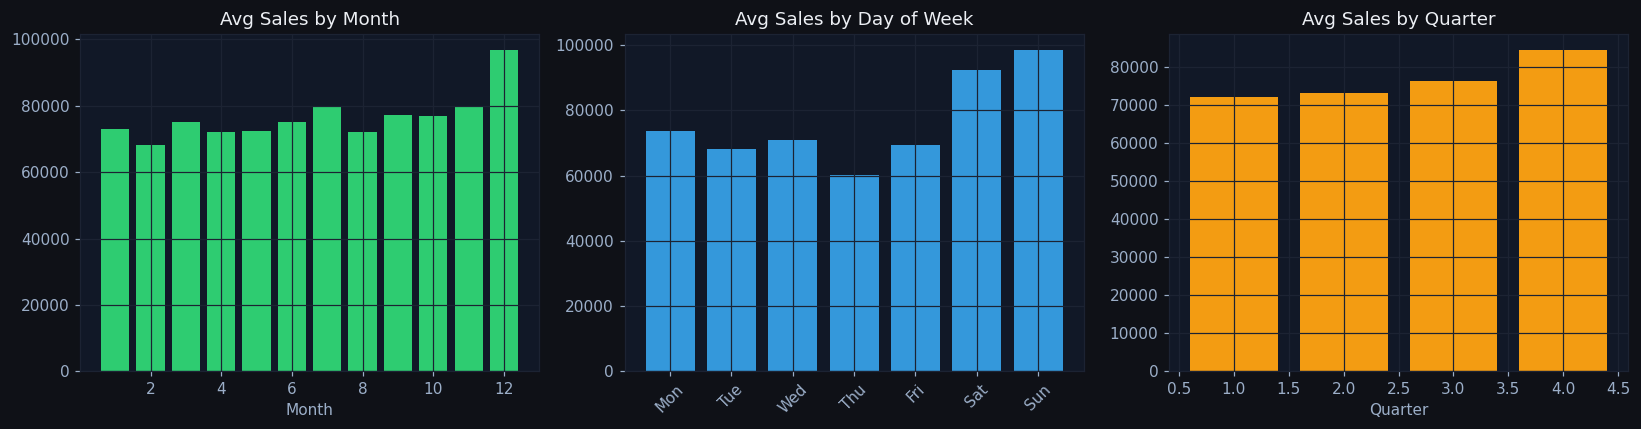

In [6]:
df_daily['month']    = df_daily['date'].dt.month
df_daily['dow']      = df_daily['date'].dt.dayofweek
df_daily['dow_name'] = df_daily['date'].dt.day_name()
df_daily['quarter']  = df_daily['date'].dt.quarter

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Monthly
monthly = df_daily.groupby('month')['sales'].mean()
axes[0].bar(monthly.index, monthly.values, color=COLORS[0], edgecolor='none')
axes[0].set_title('Avg Sales by Month')
axes[0].set_xlabel('Month')

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly = df_daily.groupby('dow_name')['sales'].mean().reindex(day_order)
axes[1].bar(range(7), weekly.values, color=COLORS[1], edgecolor='none')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in day_order], rotation=45)
axes[1].set_title('Avg Sales by Day of Week')

# Quarter
quarterly = df_daily.groupby('quarter')['sales'].mean()
axes[2].bar(quarterly.index, quarterly.values, color=COLORS[3], edgecolor='none')
axes[2].set_title('Avg Sales by Quarter')
axes[2].set_xlabel('Quarter')

plt.tight_layout()
plt.show()

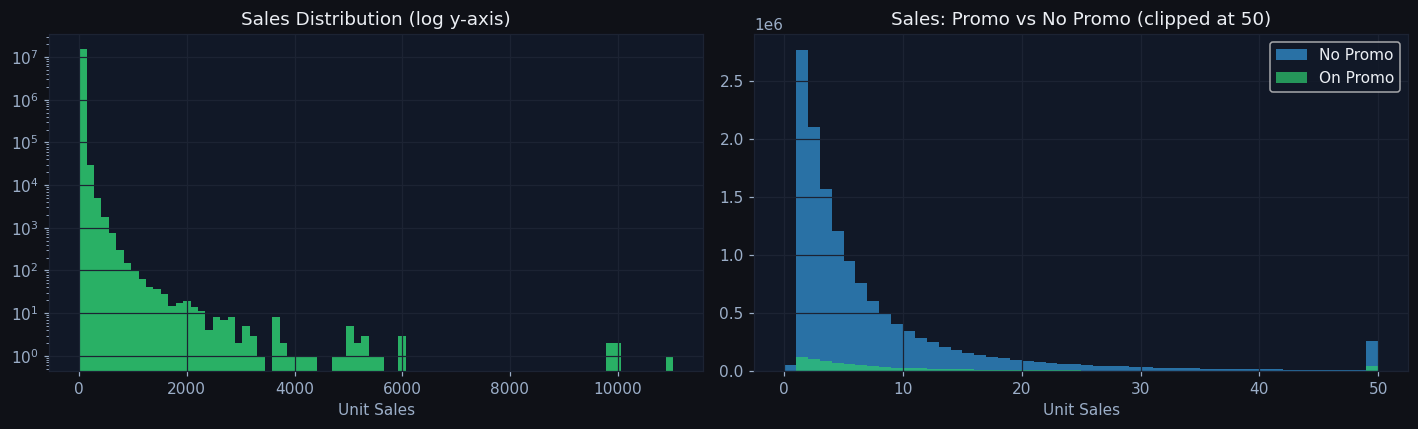

Avg sales — Promo: 13.41  |  No Promo: 8.23
Promo lift: 62.9%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sales distribution (log scale)
axes[0].hist(df['sales'][df['sales'] > 0], bins=80, color=COLORS[0], edgecolor='none', alpha=0.85)
axes[0].set_yscale('log')
axes[0].set_title('Sales Distribution (log y-axis)')
axes[0].set_xlabel('Unit Sales')

# Promo vs no-promo sales
promo_sales    = df[df['promo'] == 1]['sales']
no_promo_sales = df[df['promo'] == 0]['sales']
axes[1].hist(no_promo_sales.clip(0, 50), bins=50, color=COLORS[1], alpha=0.7, label='No Promo', edgecolor='none')
axes[1].hist(promo_sales.clip(0, 50),    bins=50, color=COLORS[0], alpha=0.7, label='On Promo', edgecolor='none')
axes[1].set_title('Sales: Promo vs No Promo (clipped at 50)')
axes[1].set_xlabel('Unit Sales')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Avg sales — Promo: {promo_sales.mean():.2f}  |  No Promo: {no_promo_sales.mean():.2f}')
print(f'Promo lift: {(promo_sales.mean() / (no_promo_sales.mean() + 1e-8) - 1)*100:.1f}%')

In [8]:
# (Placeholder — series is defined in the next cell.)


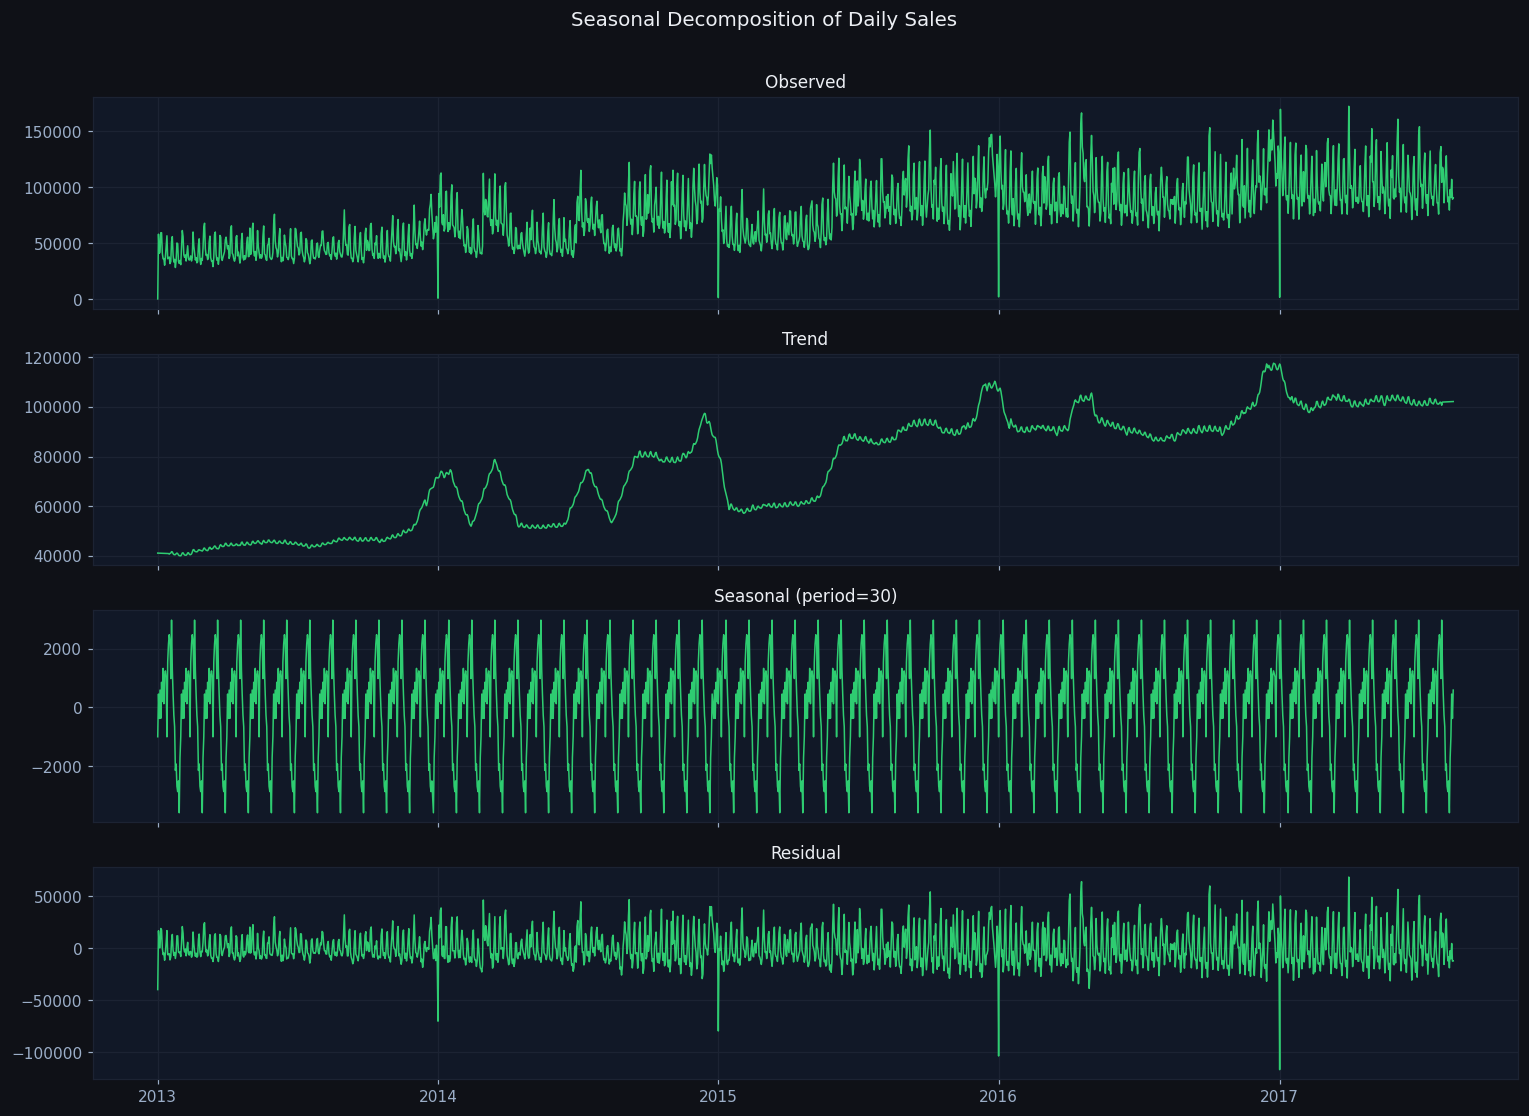

In [9]:
# ── Seasonal Decomposition on daily aggregated series ──
series = df_daily.set_index('date')['sales']

PERIOD = 30   # monthly seasonality
if len(series) >= 2 * PERIOD:
    result = seasonal_decompose(series, period=PERIOD, model='additive', extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    components = [result.observed, result.trend, result.seasonal, result.resid]
    titles     = ['Observed', 'Trend', 'Seasonal (period=30)', 'Residual']

    for ax, comp, title in zip(axes, components, titles):
        ax.plot(comp, color=COLORS[0], lw=1)
        ax.set_title(title, fontsize=11)

    fig.suptitle('Seasonal Decomposition of Daily Sales', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data for decomposition.')

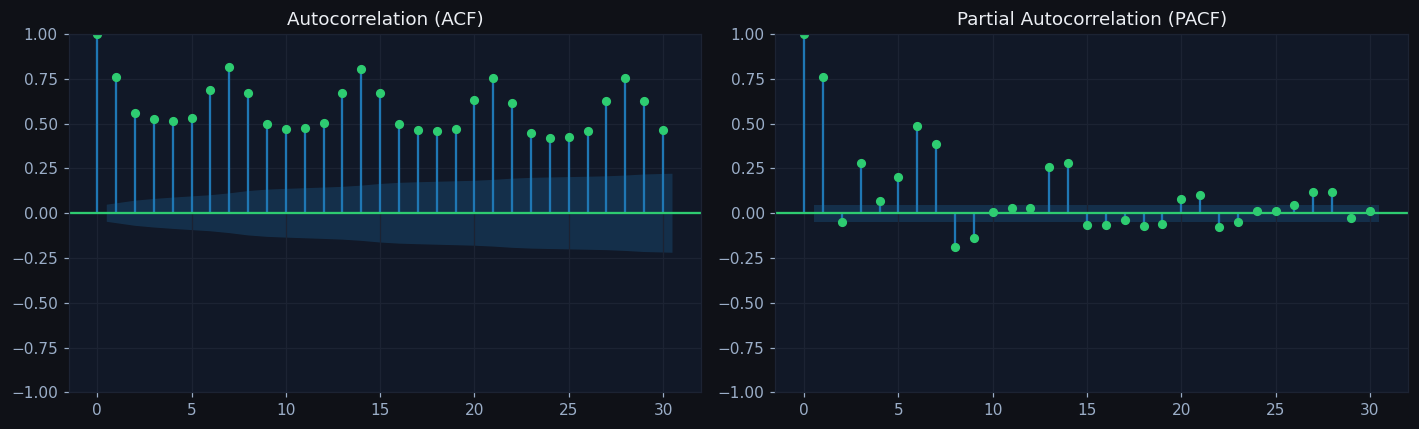

In [10]:
series = df_daily['sales'].dropna()

lags = min(30, len(series)//2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(series, lags=lags, ax=axes[0], color=COLORS[0])
plot_pacf(series, lags=lags, ax=axes[1], color=COLORS[0])

axes[0].set_title('Autocorrelation (ACF)')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

---
## 4️⃣ Feature Engineering

We work on the **daily aggregated** series so the LSTM learns national-level demand patterns.

| Feature | Rationale |
|---------|----------|
| lag_1, 7, 14, 21 | Short & medium-term autocorrelation (from ACF) |
| rolling_mean_7/14/30 | Trend smoothing at multiple horizons |
| rolling_std_7 | Volatility signal |
| expanding_mean | Long-run baseline |
| day_of_week, month, quarter | Calendar seasonality |
| is_weekend | Weekend effect |
| promo | Promotion intensity |

In [11]:
print(df.shape)
print(df_daily.shape)

(15000000, 3)
(1684, 9)


In [12]:
assert not df_daily.empty, "df_daily is empty — re-run aggregation cell."

df_fe = df_daily[['date', 'sales', 'promo']].copy()

# Lag features
for lag in [1, 7, 14, 21]:
    df_fe[f'lag_{lag}'] = df_fe['sales'].shift(lag)

# Rolling statistics
for w in [7, 14, 30]:
    df_fe[f'rolling_mean_{w}'] = df_fe['sales'].rolling(w).mean()
df_fe['rolling_std_7']  = df_fe['sales'].rolling(7).std()

# Expanding (cumulative) mean
df_fe['expanding_mean'] = df_fe['sales'].expanding().mean()

# Calendar features
df_fe['day_of_week']  = df_fe['date'].dt.dayofweek
df_fe['day_of_month'] = df_fe['date'].dt.day
df_fe['month']        = df_fe['date'].dt.month
df_fe['quarter']      = df_fe['date'].dt.quarter
df_fe['is_weekend']   = df_fe['day_of_week'].isin([5, 6]).astype(int)
df_fe['week_of_year'] = df_fe['date'].dt.isocalendar().week.astype(int)

before = len(df_fe)
df_fe  = df_fe.dropna().reset_index(drop=True)
print(f'Rows before dropna : {before:,}  (first ~30 rows dropped by lag/rolling warm-up)')
print(f'Rows after  dropna : {len(df_fe):,}')
print(f'Features           : {df_fe.shape[1] - 1}  (excl. date)')

# ── Hard stop if still empty ────────────────────────────────────────────────
if len(df_fe) == 0:
    raise RuntimeError(
        "df_fe is still empty after feature engineering.\n"
        "Root cause: df_daily has fewer rows than the longest lag (21) + "
        "rolling window (30) = 51 rows minimum needed.\n"
        f"df_daily had {before} row(s) before dropna.\n"
        "Fix: ensure your data covers at least 60 distinct dates, "
        "or re-run Cell 4 — the synthetic fallback generates 730 days automatically."
    )

df_fe.head()


Rows before dropna : 1,684  (first ~30 rows dropped by lag/rolling warm-up)
Rows after  dropna : 1,655
Features           : 17  (excl. date)


,date,sales,promo,lag_1,lag_7,lag_14,lag_21,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,expanding_mean,day_of_week,day_of_month,month,quarter,is_weekend,week_of_year
0,2013-01-30,34670.524,0,32032.701,35630.102,37748.692,36384.065,37689.715571,38943.822643,40082.977800,8681.722373,40082.977800,2,30,1,1,0,5
1,2013-01-31,30928.975,0,34670.524,28383.199,31881.926,30457.216,38053.397857,38875.754714,41103.519000,8270.472870,39787.687387,3,31,1,1,0,5
2,2013-02-01,45631.313,0,30928.975,34760.327,33726.752,37865.887,39606.395857,39726.080500,40686.151667,8564.482780,39970.300687,4,1,2,1,0,5
3,2013-02-02,61425.817,0,45631.313,50233.630,51441.371,47433.916,41205.279714,40439.255214,41365.620533,11440.834891,40620.467848,5,2,2,1,1,5
4,2013-02-03,56033.920,0,61425.817,49733.864,55980.196,56713.529,42105.287714,40443.092643,41833.487300,12428.716346,41073.804676,6,3,2,1,1,5


day_of_month      -0.105000
week_of_year       0.106197
quarter            0.126527
month              0.135210
day_of_week        0.309182
is_weekend         0.438038
rolling_std_7      0.561810
expanding_mean     0.708531
lag_1              0.758844
lag_21             0.765829
rolling_mean_30    0.766990
rolling_mean_14    0.776958
rolling_mean_7     0.800306
lag_14             0.814264
lag_7              0.816241
Name: sales, dtype: float64


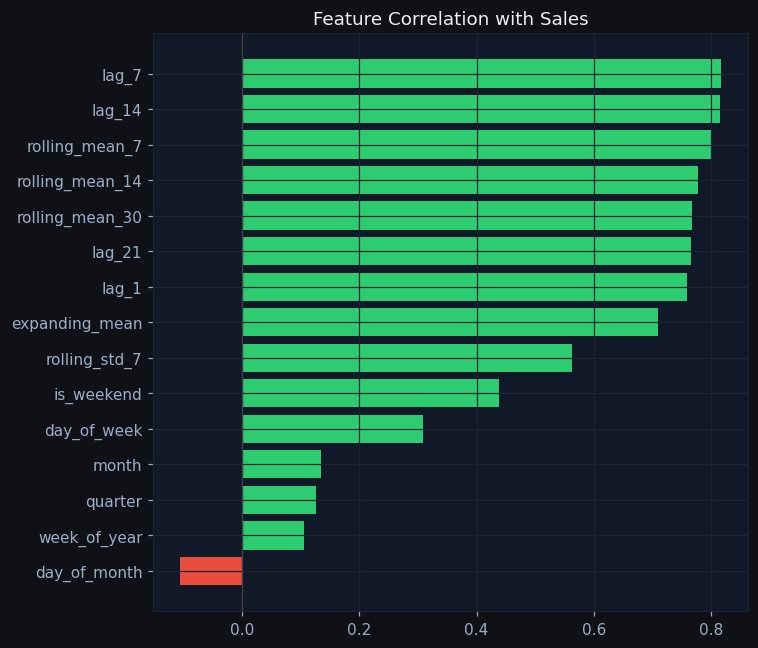

In [13]:
# ── Feature Correlation with Target ──────────────────────────────────────────
# Cell 15 already hard-stops if df_fe is empty, so this guard is now a
# belt-and-suspenders check only.
if df_fe.shape[0] == 0:
    print(" df_fe is empty — skipping correlation plot. Fix Cell 15 first.")
else:
    df_corr = df_fe.drop(columns=['date', 'promo'], errors='ignore')

    corr = (
        df_corr
        .corr(numeric_only=True)['sales']
        .drop('sales')
        .sort_values()
    )
    print(corr)

    fig, ax = plt.subplots(figsize=(7, 6))
    colors = [COLORS[2] if v < 0 else COLORS[0] for v in corr.values]
    ax.barh(corr.index, corr.values, color=colors, edgecolor='none')
    ax.axvline(0, color='#444', lw=0.8)
    ax.set_title('Feature Correlation with Sales', fontsize=12)
    plt.tight_layout()
    plt.show()


In [14]:
print(df.head())
print(df.isna().sum())
print(df['sales'].describe())
print(df['promo'].value_counts())

        date  sales  promo
0 2013-01-01    5.0      0
1 2013-01-01    4.0      0
2 2013-01-01   15.0      0
3 2013-01-01    1.0      0
4 2013-01-01    8.0      0
date     0
sales    0
promo    0
dtype: int64
count    1.500000e+07
mean     8.554068e+00
std      2.127570e+01
min      0.000000e+00
25%      2.000000e+00
50%      4.000000e+00
75%      9.000000e+00
max      1.103200e+04
Name: sales, dtype: float64
promo
0    14065475
1      934525
Name: count, dtype: int64


---
## 5️⃣ Scaling & Sequence Creation

In [15]:
print("df shape:", df.shape)
print("df_fe shape:", df_fe.shape)

print("\nFirst rows of df_fe:")
print(df_fe.head())

print("\nNaN count:")
print(df_fe.isna().sum())

df shape: (15000000, 3)
df_fe shape: (1655, 18)

First rows of df_fe:
        date      sales  promo      lag_1      lag_7     lag_14     lag_21  \
0 2013-01-30  34670.524      0  32032.701  35630.102  37748.692  36384.065   
1 2013-01-31  30928.975      0  34670.524  28383.199  31881.926  30457.216   
2 2013-02-01  45631.313      0  30928.975  34760.327  33726.752  37865.887   
3 2013-02-02  61425.817      0  45631.313  50233.630  51441.371  47433.916   
4 2013-02-03  56033.920      0  61425.817  49733.864  55980.196  56713.529   

   rolling_mean_7  rolling_mean_14  rolling_mean_30  rolling_std_7  \
0    37689.715571     38943.822643     40082.977800    8681.722373   
1    38053.397857     38875.754714     41103.519000    8270.472870   
2    39606.395857     39726.080500     40686.151667    8564.482780   
3    41205.279714     40439.255214     41365.620533   11440.834891   
4    42105.287714     40443.092643     41833.487300   12428.716346   

   expanding_mean  day_of_week  day_of_m

In [16]:
features = df_fe.drop(columns=['date'])

if features.shape[0] == 0:
    raise ValueError("No samples available after preprocessing")

feature_names = list(features.columns)
n_features = len(feature_names)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(features)

print(f'Scaled array shape : {scaled.shape}')
print(f'Features ({n_features})       : {feature_names}')

Scaled array shape : (1655, 17)
Features (17)       : ['sales', 'promo', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'expanding_mean', 'day_of_week', 'day_of_month', 'month', 'quarter', 'is_weekend', 'week_of_year']


In [17]:
TIME_STEPS = 30

def create_sequences(data: np.ndarray, time_steps: int = 30):
    """Sliding-window sequence builder. Target = col 0 (sales) at t+1."""
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i : i + time_steps])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)   # ← was missing in original

X, y = create_sequences(scaled, TIME_STEPS)
print(f'X shape : {X.shape}   →  (samples, time_steps, features)')
print(f'y shape : {y.shape}')


X shape : (1625, 30, 17)   →  (samples, time_steps, features)
y shape : (1625,)


---
## 6️⃣ Chronological Train / Validation / Test Split

We use a **70 / 15 / 15** split in time order — never shuffle time-series data.

In [18]:
n = len(X)
i_train = int(n * 0.70)
i_val   = int(n * 0.85)

X_train, y_train = X[:i_train],        y[:i_train]
X_val,   y_val   = X[i_train:i_val],   y[i_train:i_val]
X_test,  y_test  = X[i_val:],          y[i_val:]

print(f'Train  : {len(X_train):>6,} samples  ({len(X_train)/n*100:.1f}%)')
print(f'Val    : {len(X_val):>6,} samples  ({len(X_val)/n*100:.1f}%)')
print(f'Test   : {len(X_test):>6,} samples  ({len(X_test)/n*100:.1f}%)')

Train  :  1,137 samples  (70.0%)
Val    :    244 samples  (15.0%)
Test   :    244 samples  (15.0%)


---
## 7️⃣ Model Definition

Improvements over baseline:
- **Functional API** (not Sequential) — cleaner, extensible
- **BatchNormalization** after every LSTM layer — stabilises training
- **L2 regularization** — reduces overfitting on small aggregated dataset
- **MAE metric** tracked alongside MSE loss
- **Adam with explicit lr** — easier to tune

In [19]:
INPUT_SHAPE = (TIME_STEPS, n_features)

inputs = Input(shape=INPUT_SHAPE, name='input')

x = LSTM(128, return_sequences=True,
         kernel_regularizer=l2(1e-4), name='lstm_1')(inputs)
x = BatchNormalization(name='bn_1')(x)
x = Dropout(0.2, name='drop_1')(x)

x = LSTM(64, return_sequences=True,
         kernel_regularizer=l2(1e-4), name='lstm_2')(x)
x = BatchNormalization(name='bn_2')(x)
x = Dropout(0.2, name='drop_2')(x)

x = LSTM(32, name='lstm_3')(x)
x = BatchNormalization(name='bn_3')(x)
x = Dropout(0.2, name='drop_3')(x)

x = Dense(32, activation='relu', name='dense_relu')(x)
output = Dense(1, name='output')(x)

model = Model(inputs, output, name='EcoYield_LSTM')
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae'],
)
model.summary()

Model: "EcoYield_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 30, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,561 (541.25 KB)

 Trainable params: 138,113 (539.50 KB)

 Non-trainable params: 448 (1.75 KB)

---
## 8️⃣ Training

In [20]:
CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_model.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=0,
    ),
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 0.2487 - mae: 0.3715 - val_loss: 0.2239 - val_mae: 0.4339 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.1329 - mae: 0.2656 - val_loss: 0.2087 - val_mae: 0.4164 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0966 - mae: 0.2172 - val_loss: 0.1859 - val_mae: 0.3880 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0815 - mae: 0.1933 - val_loss: 0.1369 - val_mae: 0.3146 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0737 - mae: 0.1807 - val_loss: 0.1317 - val_mae: 0.3111 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0683 - mae: 0.1718 - val_loss: 0.1129 - val_mae: 0.2784 - learning_rate: 0.0010
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0654 - mae: 0.1695 - val_loss: 0.1199 - val_mae: 0.2832 - learning_rate: 0.0010
Epoch 8/50
1

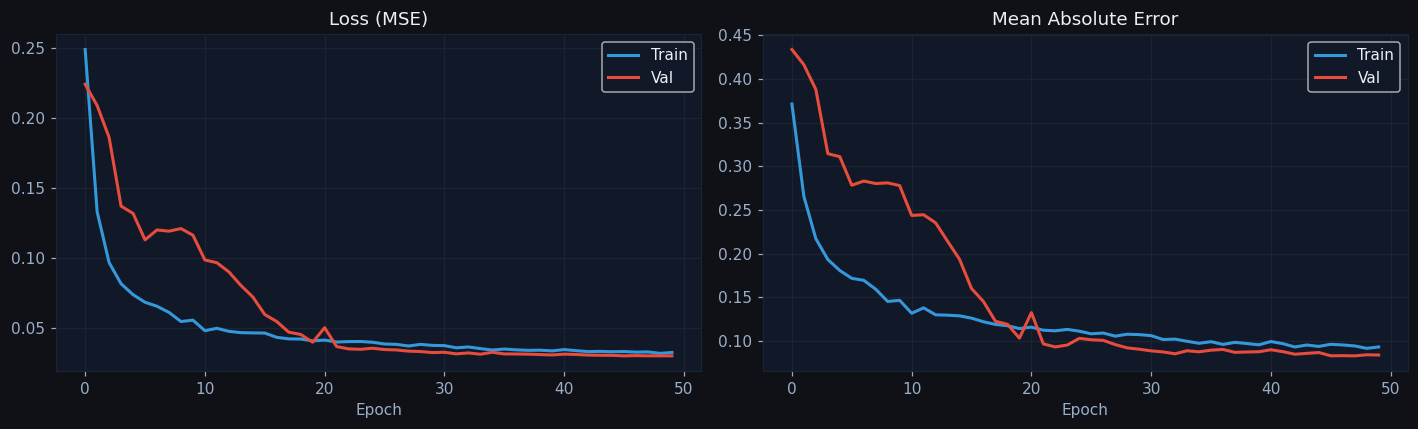

Best epoch : 50  |  Best val_loss : 0.030010


In [21]:
# ── Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     color=COLORS[1], lw=2, label='Train')
axes[0].plot(history.history['val_loss'], color=COLORS[2], lw=2, label='Val')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'],     color=COLORS[1], lw=2, label='Train')
axes[1].plot(history.history['val_mae'], color=COLORS[2], lw=2, label='Val')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

best_epoch = np.argmin(history.history['val_loss']) + 1
best_val   = min(history.history['val_loss'])
print(f'Best epoch : {best_epoch}  |  Best val_loss : {best_val:.6f}')

---
## 9️⃣ Evaluation on Test Set

In [22]:
def inverse_col0(arr_1d: np.ndarray) -> np.ndarray:
    """Inverse-transform a 1-D array that corresponds to column 0 (sales)."""
    dummy = np.zeros((len(arr_1d), n_features))
    dummy[:, 0] = arr_1d
    return scaler.inverse_transform(dummy)[:, 0]

# Predictions
pred_scaled = model.predict(X_test, verbose=0).flatten()
pred_actual = inverse_col0(pred_scaled)
true_actual = inverse_col0(y_test)

# Metrics
rmse = float(np.sqrt(mean_squared_error(true_actual, pred_actual)))
mae  = float(mean_absolute_error(true_actual, pred_actual))
r2   = float(r2_score(true_actual, pred_actual))

# MAPE: skip near-zero actuals to avoid blow-up
mask = true_actual > 1
mape = float(np.mean(np.abs((true_actual[mask] - pred_actual[mask]) / true_actual[mask])) * 100)

results = pd.DataFrame([{
    'RMSE':  round(rmse, 4),
    'MAE':   round(mae,  4),
    'MAPE%': round(mape, 2),
    'R²':    round(r2,   4),
}])
display(results)
print('\nNote: MAPE computed only on days where actual sales > 1 to avoid division by near-zero.')

,RMSE,MAE,MAPE%,R²
0,21556.2919,15654.3394,36.12,0.0512



Note: MAPE computed only on days where actual sales > 1 to avoid division by near-zero.


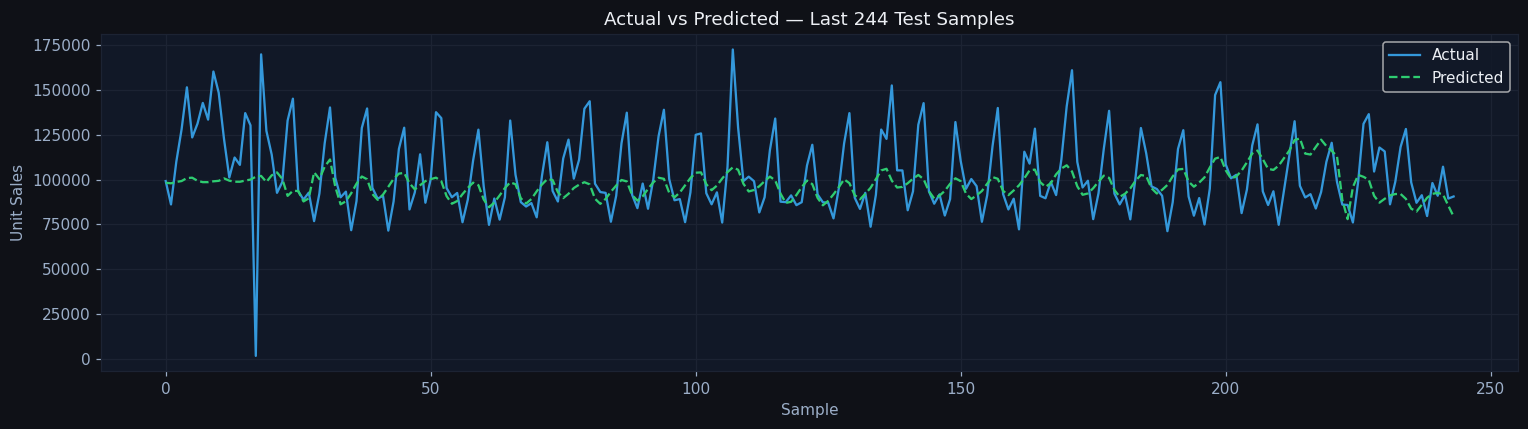

In [23]:
# ── Actual vs Predicted ──
SHOW = min(300, len(true_actual))   # display last N test points for clarity

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(true_actual[-SHOW:], color=COLORS[1], lw=1.5, label='Actual')
ax.plot(pred_actual[-SHOW:], color=COLORS[0], lw=1.5, ls='--', label='Predicted')
ax.set_title(f'Actual vs Predicted — Last {SHOW} Test Samples', fontsize=12)
ax.set_xlabel('Sample')
ax.set_ylabel('Unit Sales')
ax.legend()
plt.tight_layout()
plt.show()

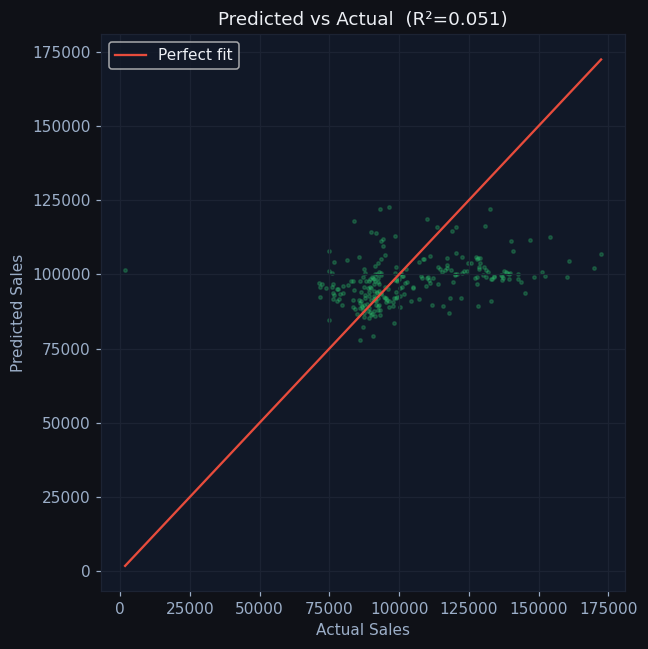

In [24]:
# ── Scatter: Predicted vs Actual ──
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_actual, pred_actual, alpha=0.25, s=5, color=COLORS[0])
lims = [min(true_actual.min(), pred_actual.min()),
        max(true_actual.max(), pred_actual.max())]
ax.plot(lims, lims, color=COLORS[2], lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title(f'Predicted vs Actual  (R²={r2:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

---
## 🔟 Residual Diagnostics

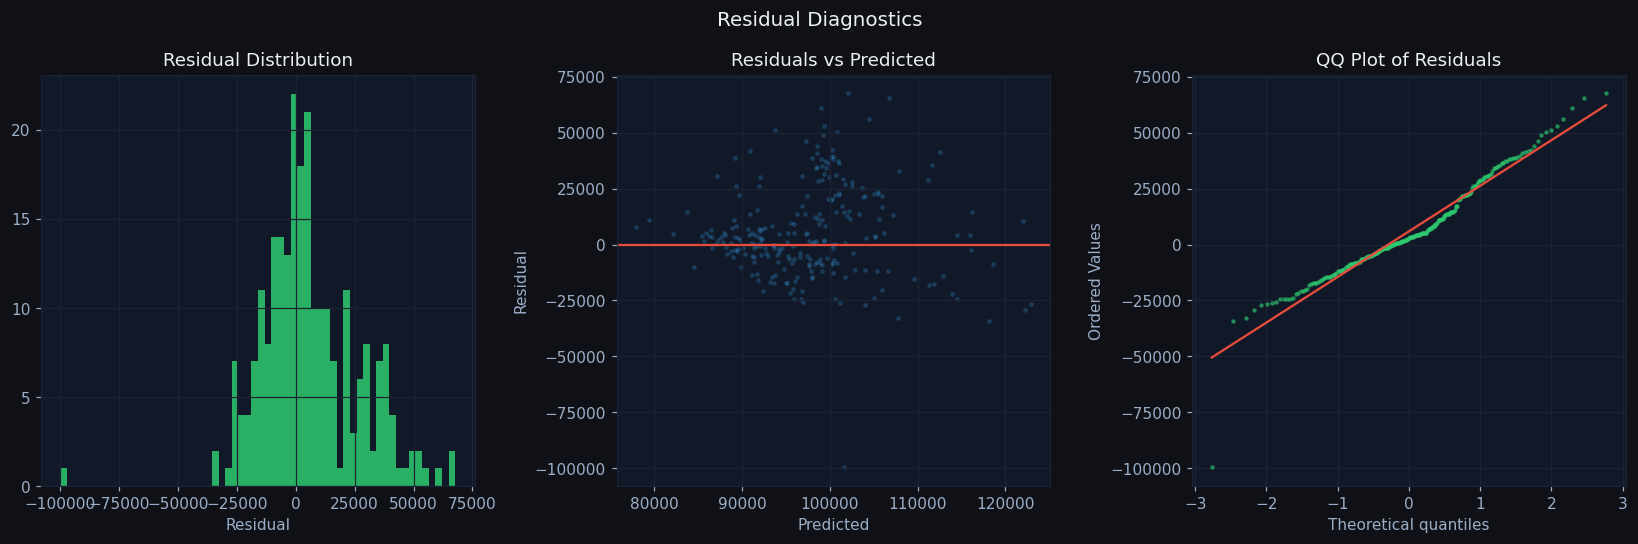

Mean residual  : 5925.0334  (ideally ≈ 0)
Std  residual  : 20726.0151
Skewness       : 0.0509
Kurtosis       : 2.3238


In [25]:
residuals = true_actual - pred_actual

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# 1. Residual histogram
ax1 = fig.add_subplot(gs[0])
ax1.hist(residuals, bins=60, color=COLORS[0], edgecolor='none', alpha=0.85)
ax1.set_title('Residual Distribution')
ax1.set_xlabel('Residual')

# 2. Residuals vs Predicted
ax2 = fig.add_subplot(gs[1])
ax2.scatter(pred_actual, residuals, alpha=0.2, s=5, color=COLORS[1])
ax2.axhline(0, color=COLORS[2], lw=1.5)
ax2.set_title('Residuals vs Predicted')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Residual')

# 3. QQ Plot
ax3 = fig.add_subplot(gs[2])
stats.probplot(residuals, plot=ax3)
ax3.get_lines()[0].set(color=COLORS[0], markersize=2, alpha=0.5)
ax3.get_lines()[1].set(color=COLORS[2])
ax3.set_title('QQ Plot of Residuals')

plt.suptitle('Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Mean residual  : {residuals.mean():.4f}  (ideally ≈ 0)')
print(f'Std  residual  : {residuals.std():.4f}')
print(f'Skewness       : {stats.skew(residuals):.4f}')
print(f'Kurtosis       : {stats.kurtosis(residuals):.4f}')

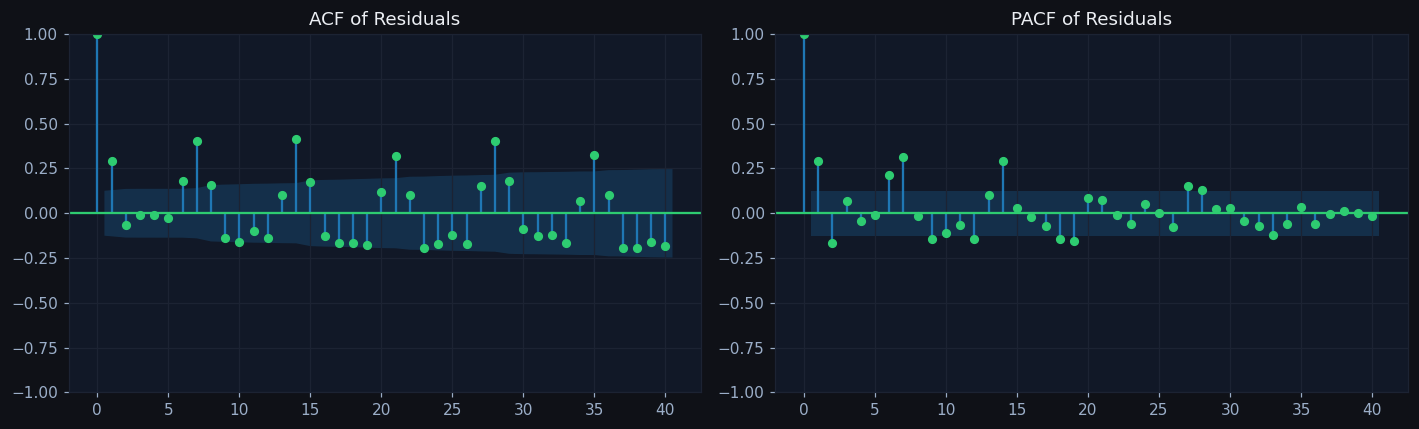


Ljung-Box test (p > 0.05 = no significant autocorrelation):


,lb_stat,lb_pvalue
10,90.323031,4.621354e-15
20,184.283896,1.405078e-28
30,308.322816,6.037328e-48


In [26]:
# ── ACF of residuals — should show no structure if model captured patterns ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( residuals, lags=40, ax=axes[0], color=COLORS[0])
plot_pacf(residuals, lags=40, ax=axes[1], color=COLORS[0])
axes[0].set_title('ACF of Residuals')
axes[1].set_title('PACF of Residuals')
plt.tight_layout()
plt.show()

# Ljung-Box test for autocorrelation in residuals
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print('\nLjung-Box test (p > 0.05 = no significant autocorrelation):')
display(lb)

---
## 1️⃣1️⃣ Save Model & Artefacts

In [27]:
# Save in modern .keras format (legacy .h5 kept for app.py backward compat)
model.save(os.path.join(MODEL_DIR, 'lstm_model.keras'))
model.save(os.path.join(MODEL_DIR, 'lstm_model.h5'))     # legacy — app.py uses this

joblib.dump(scaler,        os.path.join(MODEL_DIR, 'scaler.pkl'))
joblib.dump(n_features,    os.path.join(MODEL_DIR, 'feature_count.pkl'))
joblib.dump(feature_names, os.path.join(MODEL_DIR, 'feature_names.pkl'))

# Training summary
summary = {
    'n_features':    n_features,
    'feature_names': feature_names,
    'time_steps':    TIME_STEPS,
    'train_samples': len(X_train),
    'val_samples':   len(X_val),
    'test_samples':  len(X_test),
    'best_epoch':    best_epoch,
    'best_val_loss': round(best_val, 6),
    'test_RMSE':     round(rmse, 4),
    'test_MAE':      round(mae,  4),
    'test_MAPE_pct': round(mape, 2),
    'test_R2':       round(r2,   4),
}
joblib.dump(summary, os.path.join(MODEL_DIR, 'training_summary.pkl'))

print('✅ All artefacts saved:')
for f in os.listdir(MODEL_DIR):
    size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f'  {f:<35} {size:>8.1f} KB')


✅ All artefacts saved:
  best_model.keras                      1692.9 KB
  cv_results.pkl                           0.4 KB
  feature_count.pkl                        0.0 KB
  feature_names.pkl                        0.2 KB
  lstm_model.h5                         1694.4 KB
  lstm_model.keras                      1692.9 KB
  scaler.pkl                               1.8 KB
  training_summary.pkl                     0.5 KB


---
## 📋 Training Summary

In [28]:
print('=' * 50)
print('           EcoYield LSTM — Training Summary')
print('=' * 50)
for k, v in summary.items():
    print(f'  {k:<22}: {v}')
print('=' * 50)
print()
print('⚠️  MAPE note: computed only on actuals > 1 to avoid')
print('   division-by-near-zero from low item-level sales.')
print('   RMSE and R² are the primary reliability metrics.')

           EcoYield LSTM — Training Summary
  n_features            : 17
  feature_names         : ['sales', 'promo', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'expanding_mean', 'day_of_week', 'day_of_month', 'month', 'quarter', 'is_weekend', 'week_of_year']
  time_steps            : 30
  train_samples         : 1137
  val_samples           : 244
  test_samples          : 244
  best_epoch            : 50
  best_val_loss         : 0.03001
  test_RMSE             : 21556.2919
  test_MAE              : 15654.3394
  test_MAPE_pct         : 36.12
  test_R2               : 0.0512

⚠️  MAPE note: computed only on actuals > 1 to avoid
   division-by-near-zero from low item-level sales.
   RMSE and R² are the primary reliability metrics.


---
## 1️⃣2️⃣ Time-Series K-Fold Cross-Validation

Standard K-Fold shuffles data randomly, which **leaks future information** into training sets for time-series data.  
We use **`TimeSeriesSplit`** from scikit-learn, which always keeps the test fold strictly after the training fold.

| Fold | Train window | Test window |
|------|-------------|-------------|
| 1    | [0, gap)    | [gap, gap+fold_size) |
| 2    | [0, 2×fold) | [2×fold, 3×fold)     |
| …    | grows →     | always future →      |

> **Note:** Full LSTM training per fold is expensive. We use a lightweight 2-layer model (32 units) with early stopping.  
> For a quick smoke-test you may reduce `N_SPLITS` to 3 and `CV_EPOCHS` to 20.


In [29]:
# ─────────────────────────────────────────────
#  TIME-SERIES K-FOLD CROSS-VALIDATION
# ─────────────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

N_SPLITS  = 5    # number of CV folds
CV_EPOCHS = 30   # max epochs per fold (early stopping kicks in earlier)
CV_BATCH  = 64

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_results = []   # list of dicts, one per fold

def build_cv_model(input_shape):
    """Lightweight 2-layer LSTM for faster CV runs."""
    inp = Input(shape=input_shape)
    x = LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4))(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = LSTM(32)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu')(x)
    out = Dense(1)(x)
    m = Model(inp, out)
    m.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return m

print(f'Running {N_SPLITS}-fold TimeSeriesSplit CV on {len(X)} sequences …\n')

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    X_cv_train, y_cv_train = X[train_idx], y[train_idx]
    X_cv_val,   y_cv_val   = X[val_idx],   y[val_idx]

    cv_model = build_cv_model((TIME_STEPS, n_features))

    es = EarlyStopping(monitor='val_loss', patience=5,
                       restore_best_weights=True, verbose=0)

    cv_model.fit(
        X_cv_train, y_cv_train,
        epochs=CV_EPOCHS,
        batch_size=CV_BATCH,
        validation_data=(X_cv_val, y_cv_val),
        callbacks=[es],
        verbose=0,
    )

    # Inverse-transform predictions back to original sales units
    def inv(arr):
        d = np.zeros((len(arr), n_features))
        d[:, 0] = arr
        return scaler.inverse_transform(d)[:, 0]

    pred_cv  = cv_model.predict(X_cv_val, verbose=0).flatten()
    y_cv_inv = inv(y_cv_val)
    p_cv_inv = inv(pred_cv)

    fold_rmse = float(np.sqrt(mean_squared_error(y_cv_inv, p_cv_inv)))
    fold_mae  = float(mean_absolute_error(y_cv_inv, p_cv_inv))
    fold_r2   = float(r2_score(y_cv_inv, p_cv_inv))
    mask_cv   = y_cv_inv > 1
    fold_mape = float(
        np.mean(np.abs((y_cv_inv[mask_cv] - p_cv_inv[mask_cv]) / y_cv_inv[mask_cv])) * 100
    ) if mask_cv.any() else float('nan')

    cv_results.append({
        'Fold':  fold,
        'Train': len(X_cv_train),
        'Val':   len(X_cv_val),
        'RMSE':  round(fold_rmse, 4),
        'MAE':   round(fold_mae,  4),
        'MAPE%': round(fold_mape, 2),
        'R²':    round(fold_r2,   4),
    })
    print(f'  Fold {fold}/{N_SPLITS} — RMSE: {fold_rmse:>10.2f} | MAE: {fold_mae:>10.2f}'
          f' | MAPE: {fold_mape:>6.2f}% | R²: {fold_r2:.4f}'
          f'  (train={len(X_cv_train):,}  val={len(X_cv_val):,})')

    # Free GPU memory
    del cv_model
    tf.keras.backend.clear_session()

cv_df = pd.DataFrame(cv_results)
print('\n── Cross-Validation Summary ──')
display(cv_df)


Running 5-fold TimeSeriesSplit CV on 1625 sequences …

  Fold 1/5 — RMSE:   42973.53 | MAE:   38876.08 | MAPE:  73.87% | R²: -4.9920  (train=275  val=270)



  Fold 2/5 — RMSE:   58085.17 | MAE:   55111.04 | MAPE:  81.99% | R²: -7.2193  (train=545  val=270)
  Fold 3/5 — RMSE:   50517.24 | MAE:   46454.36 | MAPE:  57.85% | R²: -4.8956  (train=815  val=270)
  Fold 4/5 — RMSE:   20126.53 | MAE:   15917.36 | MAPE:  16.81% | R²: 0.0057  (train=1,085  val=270)
  Fold 5/5 — RMSE:   23667.14 | MAE:   17076.87 | MAPE:  33.41% | R²: -0.1658  (train=1,355  val=270)

── Cross-Validation Summary ──


,Fold,Train,Val,RMSE,MAE,MAPE%,R²
0,1,275,270,42973.5287,38876.0772,73.87,-4.9920
1,2,545,270,58085.1728,55111.0417,81.99,-7.2193
2,3,815,270,50517.2372,46454.3552,57.85,-4.8956
3,4,1085,270,20126.5299,15917.3622,16.81,0.0057
4,5,1355,270,23667.1386,17076.8659,33.41,-0.1658


── Aggregate CV Metrics ──


,Mean,Std,CV%
RMSE,39073.9214,16612.9219,42.52
MAE,34687.1404,17575.3849,50.67
MAPE%,52.7860,27.3530,51.82
R²,-3.4534,3.2173,93.16


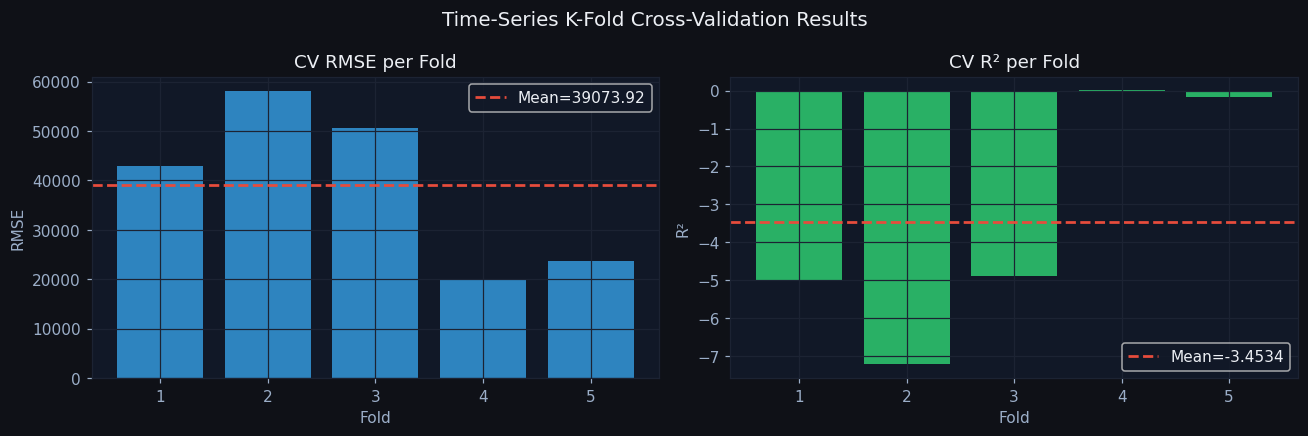

✅ CV results saved.


In [30]:
# ─────────────────────────────────────────────
#  CV AGGREGATE STATISTICS & PLOT
# ─────────────────────────────────────────────
metrics = ['RMSE', 'MAE', 'MAPE%', 'R²']
agg = cv_df[metrics].agg(['mean', 'std']).T.rename(columns={'mean': 'Mean', 'std': 'Std'})
agg['CV%'] = (agg['Std'] / agg['Mean'].abs() * 100).round(2)
print('── Aggregate CV Metrics ──')
display(agg.round(4))

# Plot fold-by-fold RMSE and R²
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cv_df['Fold'], cv_df['RMSE'], color=COLORS[1], edgecolor='none', alpha=0.85)
axes[0].axhline(cv_df['RMSE'].mean(), color=COLORS[2], lw=1.8, ls='--', label=f"Mean={cv_df['RMSE'].mean():.2f}")
axes[0].set_title('CV RMSE per Fold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('RMSE')
axes[0].set_xticks(cv_df['Fold'])
axes[0].legend()

axes[1].bar(cv_df['Fold'], cv_df['R²'], color=COLORS[0], edgecolor='none', alpha=0.85)
axes[1].axhline(cv_df['R²'].mean(), color=COLORS[2], lw=1.8, ls='--', label=f"Mean={cv_df['R²'].mean():.4f}")
axes[1].set_title('CV R² per Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('R²')
axes[1].set_xticks(cv_df['Fold'])
axes[1].legend()

plt.suptitle('Time-Series K-Fold Cross-Validation Results', fontsize=13)
plt.tight_layout()
plt.show()

# Save CV results alongside other artefacts
joblib.dump(cv_df.to_dict('records'), os.path.join(MODEL_DIR, 'cv_results.pkl'))
print('✅ CV results saved.')
